# Download e Librerie

In [1]:
from dynabench.dataset import download_equation, DynabenchIterator
import matplotlib.pyplot as plt
import numpy as np


/home/matteo/matteo/UNIVERSITA/magistrale/PINN/progetto/pinn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
os.makedirs("./data", exist_ok=True)
os.environ["DYNABENCH_ROOT"] = "./data"

tipo sample: <class 'dynabench.dataset._dataitems.DataItem'>
shape x: (2, 225, 1)
shape y: (2, 225, 1)
shape points: (225, 2)


/tmp/ipykernel_11376/2067963345.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


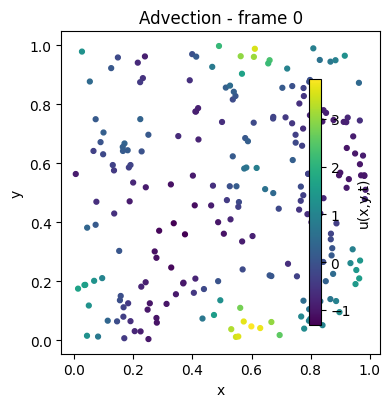

In [4]:

# # 1) Scarica la prima equazione del benchmark: advection
# download_equation(
#     equation="advection",
#     structure="cloud",
#     resolution="low",
# )

# 2) Crea l'iteratore
iterator = DynabenchIterator(
    equation="advection",
    structure="cloud",
    resolution="low",
    lookback=2,
    rollout=2,
)

# 2) Prendi il primo sample
sample = next(iter(iterator))   # oppure: sample = iterator[0]

# 3) Estrai i campi
x = sample.x
y = sample.y
points = sample.pos

print("tipo sample:", type(sample))
print("shape x:", x.shape)
print("shape y:", y.shape)
print("shape points:", points.shape)

# 4) Plot
num_frames_to_plot = min(1, x.shape[0])
vmin = np.min(x[:, :, 0])
vmax = np.max(x[:, :, 0])

fig, axes = plt.subplots(1, num_frames_to_plot, figsize=(4 * num_frames_to_plot, 4))

if num_frames_to_plot == 1:
    axes = [axes]

for t in range(num_frames_to_plot):
    sc = axes[t].scatter(
        points[:, 0],
        points[:, 1],
        c=x[t, :, 0],
        s=12,
        vmin=vmin,
        vmax=vmax
    )
    axes[t].set_title(f"Advection - frame {t}")
    axes[t].set_xlabel("x")
    axes[t].set_ylabel("y")
    axes[t].set_aspect("equal")

fig.colorbar(sc, ax=axes, shrink=0.8, label="u(x,y,t)")
plt.tight_layout()
plt.show()

# x sono n punti nel passato, 225 sono i punti spaziali e 1 è la variabile fisica… e y stessa cosa ma nel futuro

# Head

In [ ]:
print(x[0, :10, 0])
print(y[0, :10, 0])


In [ ]:
print("min:", x.min())
print("max:", x.max())
print("mean:", x.mean())

In [ ]:
plt.scatter(points[:, 0], points[:, 1], c=(y[0,:,0] - x[0,:,0]))
plt.colorbar()
plt.title("Differenza y - x")
plt.show()